# Week 3 — PCA denoising of a synthetic EELS line-scan

**Course:** Data Science for Electron Microscopy — FAU Erlangen-Nürnberg  
**Author:** Prof. Dr. Philipp Pelz  
**Prerequisites:** Week 1 (NumPy, matplotlib) · Week 2 (Poisson noise, SNR)  
**Time budget:** ~90 minutes for a beginner working steadily

## What you will do

1. Build a **synthetic EELS spectral line scan** with two latent chemical components and Poisson noise.
2. Compute the **SVD** of the centered data matrix.
3. Plot the **scree plot** (variance per component) and cumulative-variance curve.
4. **Reconstruct** the stack with different numbers of components; observe that the optimal K is at the scree-plot elbow.
5. **Exercise:** choose K yourself and justify from the scree plot.

## How to use this notebook

All exercise code cells ship a **working version** with `# (try this yourself)` markers.  
**Instructions:** before running those cells, try to write the code yourself (the comment tells you which lines to try).  
A separate **Solution** markdown cell follows each exercise with a plain-code block.  
Run `nbconvert --execute` end-to-end any time — it will always succeed.

---

In [1]:
# --- Cell 1: Install and import ---
# Run this cell first (works on Colab; harmless on a local install)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "numpy", "matplotlib",
                "scikit-learn", "--quiet"], check=True)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)
print("Imports OK — NumPy", np.__version__)

Imports OK — NumPy 1.26.4


## Part 1 — Build the synthetic EELS stack

We simulate a 1-D spatial scan of 64 pixels, each with a 300-channel EELS spectrum.  
Two latent chemical components vary **independently** across the scan:

- **Component A (Fe-L edge, ~710 eV):** Gaussian bump centred in the scan (`exp(-((x-0.5)/0.15)²)`).
- **Component B (Cr-L edge, ~580 eV):** linearly decreasing from left to right (`1 - x`).

The two weight functions are **uncorrelated** (correlation ≈ 0), giving a rank-2 clean signal.  
Noise is added with `np.random.poisson` — the correct model for electron counting detectors.

In [2]:
# --- Cell 2: Define spectral components and spatial weights ---

nx    = 64           # number of spatial pixels along the line scan
ne    = 300          # number of energy channels
SCALE = 500.0        # detector gain (electrons per unit intensity)

energy = np.linspace(500, 900, ne)   # energy axis in eV

def gaussian(e, mu, sig, h):
    """Gaussian peak: centre mu (eV), width sig (eV), height h."""
    return h * np.exp(-0.5 * ((e - mu) / sig) ** 2)

# Spectral shapes for the two latent components
comp_fe = (gaussian(energy, 710, 20, 1.0)     # Fe-L3 white-line
         + gaussian(energy, 700,  8, 0.4))    # Fe-L2 shoulder

comp_cr = gaussian(energy, 580, 18, 0.8)      # Cr-L2,3 edge

# Constant background (will be absorbed into the mean spectrum after centering)
background_level = 0.30

# Spatial weight functions — designed to be UNCORRELATED
x = np.linspace(0, 1, nx)
weight_fe = np.exp(-((x - 0.5) / 0.15) ** 2)   # Gaussian bump at centre
weight_cr = 1.0 - x                              # linearly decreasing, left-to-right

# Build the clean signal matrix: shape (nx, ne)
clean = (np.outer(weight_fe, comp_fe)
       + np.outer(weight_cr, comp_cr)
       + background_level)          # constant background added uniformly

# Sanity checks
assert clean.min() > 0, "Clean signal must be strictly positive for Poisson sampling"
corr = np.corrcoef(weight_fe, weight_cr)[0, 1]
print(f"Spatial weight correlation (Fe vs Cr): {corr:.3f}  (should be ≈ 0)")
print(f"clean.shape: {clean.shape}   min: {clean.min():.3f}   max: {clean.max():.3f}")

Spatial weight correlation (Fe vs Cr): -0.000  (should be ≈ 0)
clean.shape: (64, 300)   min: 0.300   max: 1.609


Image-average SNR ≈ √(mean_counts) = 13.8
noisy.shape: (64, 300)


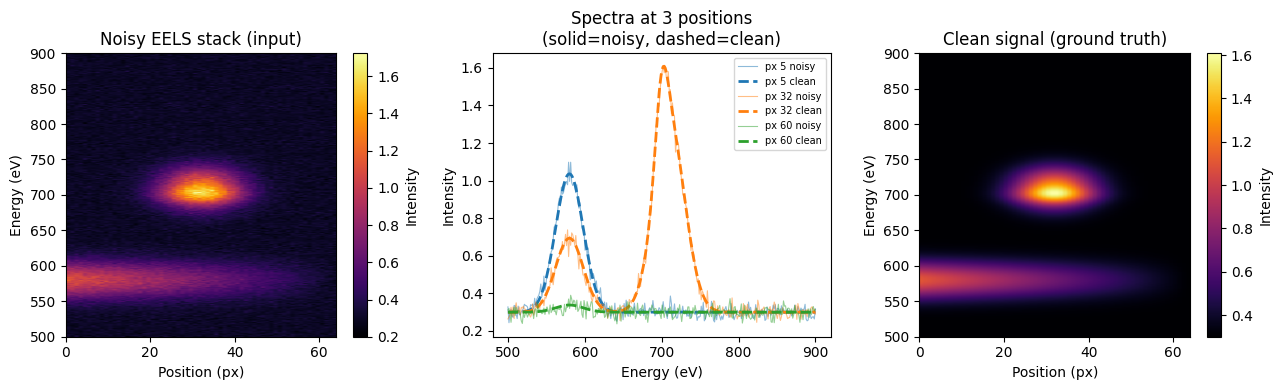


Fe-L edge: bright band ~710 eV, strongest in the centre (Gaussian bump).
Cr-L edge: bright band ~580 eV, strongest at the left edge (linear decrease).


In [3]:
# --- Cell 3: Add Poisson noise ---

noisy = rng.poisson(clean * SCALE).astype(np.float64) / SCALE

snr_avg = np.sqrt(clean.mean() * SCALE)
print(f"Image-average SNR ≈ √(mean_counts) = {snr_avg:.1f}")
print(f"noisy.shape: {noisy.shape}")

# ── Quick visualisation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

im0 = axes[0].imshow(noisy.T, aspect='auto', origin='lower',
                     extent=[0, nx, energy[0], energy[-1]], cmap='inferno')
axes[0].set_title('Noisy EELS stack (input)')
axes[0].set_xlabel('Position (px)')
axes[0].set_ylabel('Energy (eV)')
plt.colorbar(im0, ax=axes[0], label='Intensity')

for idx, col in [(5, 'C0'), (32, 'C1'), (60, 'C2')]:
    axes[1].plot(energy, noisy[idx], lw=0.8, color=col, alpha=0.5, label=f'px {idx} noisy')
    axes[1].plot(energy, clean[idx], lw=2,   color=col, linestyle='--', label=f'px {idx} clean')
axes[1].set_title('Spectra at 3 positions\n(solid=noisy, dashed=clean)')
axes[1].set_xlabel('Energy (eV)')
axes[1].set_ylabel('Intensity')
axes[1].legend(fontsize=7)

im2 = axes[2].imshow(clean.T, aspect='auto', origin='lower',
                     extent=[0, nx, energy[0], energy[-1]], cmap='inferno')
axes[2].set_title('Clean signal (ground truth)')
axes[2].set_xlabel('Position (px)')
axes[2].set_ylabel('Energy (eV)')
plt.colorbar(im2, ax=axes[2], label='Intensity')

plt.tight_layout()
plt.show()
print("\nFe-L edge: bright band ~710 eV, strongest in the centre (Gaussian bump).")
print("Cr-L edge: bright band ~580 eV, strongest at the left edge (linear decrease).")

## Part 2 — Compute the SVD

PCA is SVD of the **centered** data matrix.  
We subtract the mean spectrum (averaged over all pixels) from every row.

In [4]:
# --- Cell 4: Center and compute SVD ---

mean_spectrum = noisy.mean(axis=0)                           # (ne,) — average over pixels
X_centered    = noisy - mean_spectrum[np.newaxis, :]        # broadcast: subtract from every row

# SVD: X_centered = U @ diag(s) @ Vt
U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)

print("U.shape  :", U.shape)     # (nx, min(nx, ne))
print("s.shape  :", s.shape)     # (min(nx, ne),) — singular values, descending
print("Vt.shape :", Vt.shape)    # (min(nx, ne), ne)
print("First 10 singular values:", s[:10].round(3))
print("Note: the first two are much larger than the rest — those are the signal components.")

U.shape  : (64, 64)
s.shape  : (64,)
Vt.shape : (64, 300)
First 10 singular values: [16.86   9.14   0.703  0.677  0.672  0.655  0.642  0.62   0.615  0.607]
Note: the first two are much larger than the rest — those are the signal components.


## Part 3 — The scree plot

The scree plot shows the **variance explained** by each principal component in decreasing order.  
Signal components form a steeply declining head; noise components form a flat floor.  
The **elbow** — where the curve transitions from steep to flat — marks the signal-noise boundary.

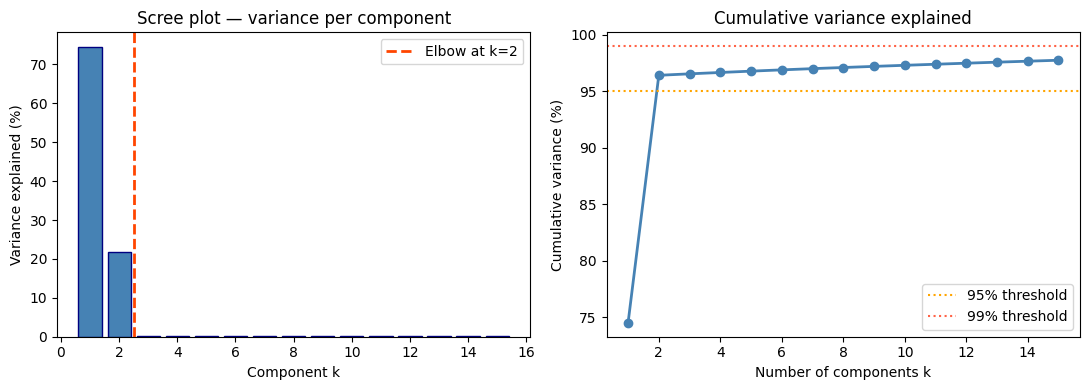

Variance: PC1=74.5%  PC2=21.9%  PC3=0.13%
Cumulative k=2: 96.4%
Components needed for 95% variance: 2


In [5]:
# --- Cell 5: Scree plot ---

var_explained = (s ** 2) / (s ** 2).sum() * 100   # percentage of total variance
cum_var       = np.cumsum(var_explained)           # cumulative

k_show = min(len(s), 15)   # show first 15 components

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: individual explained variance (scree plot) ─────────────────────────
axes[0].bar(np.arange(1, k_show + 1), var_explained[:k_show],
            color='steelblue', edgecolor='navy')
axes[0].axvline(2.5, color='orangered', lw=2, linestyle='--', label='Elbow at k=2')
axes[0].set_title('Scree plot — variance per component')
axes[0].set_xlabel('Component k')
axes[0].set_ylabel('Variance explained (%)')
axes[0].legend()

# ── Right: cumulative explained variance ────────────────────────────────────
axes[1].plot(np.arange(1, k_show + 1), cum_var[:k_show], 'o-', color='steelblue', lw=2)
axes[1].axhline(95, color='orange', lw=1.5, linestyle=':', label='95% threshold')
axes[1].axhline(99, color='tomato', lw=1.5, linestyle=':', label='99% threshold')
axes[1].set_title('Cumulative variance explained')
axes[1].set_xlabel('Number of components k')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Variance: PC1={var_explained[0]:.1f}%  PC2={var_explained[1]:.1f}%  PC3={var_explained[2]:.2f}%")
print(f"Cumulative k=2: {cum_var[1]:.1f}%")
k_95 = int(np.searchsorted(cum_var, 95)) + 1
print(f"Components needed for 95% variance: {k_95}")

**What you should see:**

- PC1 and PC2 bars are **much taller** than PC3+. These capture the two chemical components.
- PC3 onwards shows a flat noise floor — all roughly equal.
- The **elbow** is between k=2 and k=3.  
- Cumulative variance reaches ~95–97% with just K=2 components.

The scree plot tells you: **keep K=2 components**.

## Part 4 — Reconstruction with different K

We reconstruct the stack using K = 1, 2, 5, and 10 components.  
Then we measure the reconstruction error (Frobenius norm) against the clean ground truth.

In [6]:
# --- Cell 6: Helper functions for reconstruction and error ---

def reconstruct_pca(mean_spectrum, U, s, Vt, k):
    """Reconstruct data matrix keeping only the top-k singular components.

    Parameters
    ----------
    mean_spectrum : (D,) mean spectrum of the original data
    U, s, Vt      : SVD outputs from np.linalg.svd(X_centered, full_matrices=False)
    k             : number of components to keep

    Returns
    -------
    recon : (N, D) reconstructed (denoised) data matrix
    """
    recon_centered = (U[:, :k] * s[:k]) @ Vt[:k, :]   # truncated SVD reconstruction
    return recon_centered + mean_spectrum[np.newaxis, :]  # restore mean


def frob_error(recon, reference):
    """Frobenius norm of reconstruction error vs reference."""
    return np.sqrt(((recon - reference) ** 2).sum())


# Print error table
k_values = [1, 2, 3, 5, 10, 20]
print("K  | Frobenius error vs clean ground truth")
print("-" * 40)
for k in k_values:
    e = frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, k), clean)
    print(f"K={k:2d} | {e:.4f}")
print(f"\nNoisy baseline (no denoising): {frob_error(noisy, clean):.4f}")

K  | Frobenius error vs clean ground truth
----------------------------------------
K= 1 | 9.1948
K= 2 | 0.9122
K= 3 | 1.1520
K= 5 | 1.4953
K=10 | 2.0517
K=20 | 2.7170

Noisy baseline (no denoising): 3.8048


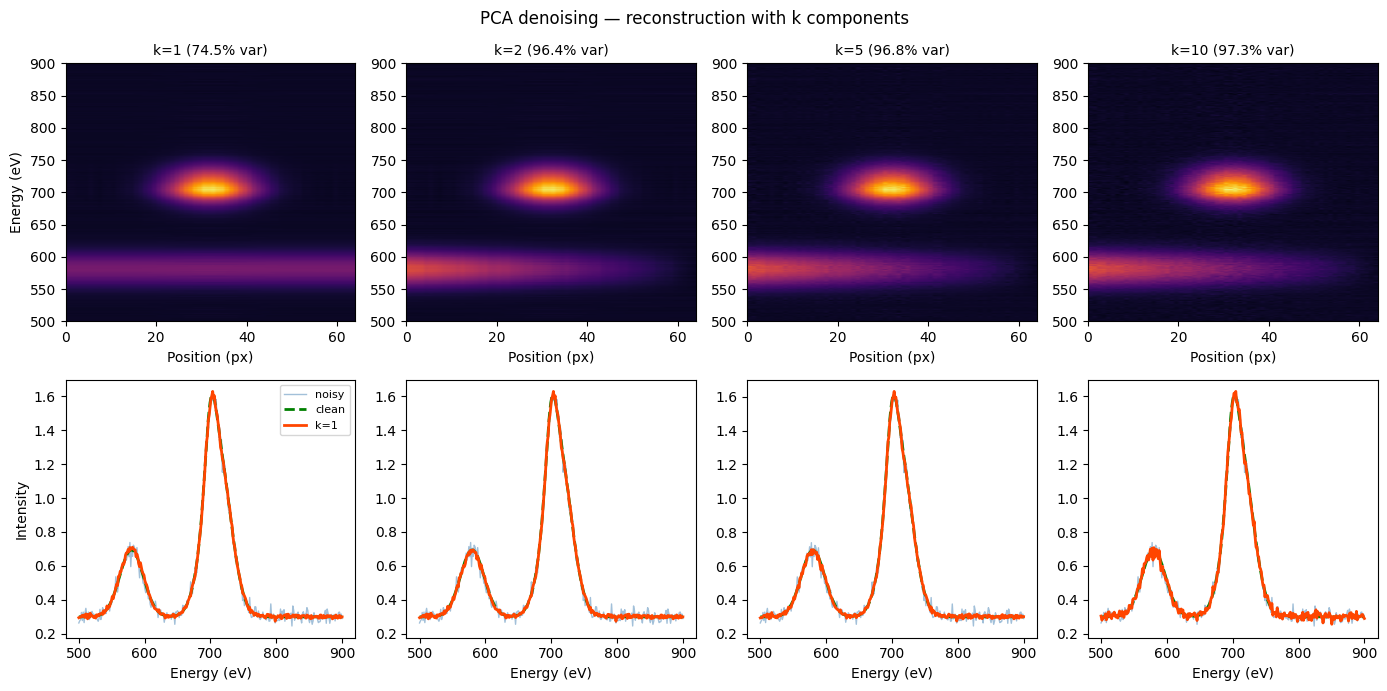

k=1 : missing the Cr-L component — underfitting (systematic error).
k=2 : closely matches clean ground truth — optimal.
k=5, 10 : extra noise components added back in — overfitting (higher error).


In [7]:
# --- Cell 7: Visualise reconstructions ---

pixel_to_show = 32   # spectrum near the centre of the scan
k_plot = [1, 2, 5, 10]

fig, axes = plt.subplots(2, len(k_plot), figsize=(14, 7))

for col, k in enumerate(k_plot):
    recon = reconstruct_pca(mean_spectrum, U, s, Vt, k)
    pct   = (s[:k] ** 2).sum() / (s ** 2).sum() * 100

    # Top row: spectral image
    axes[0][col].imshow(recon.T, aspect='auto', origin='lower',
                        extent=[0, nx, energy[0], energy[-1]],
                        cmap='inferno', vmin=noisy.min(), vmax=noisy.max())
    axes[0][col].set_title(f'k={k} ({pct:.1f}% var)', fontsize=10)
    axes[0][col].set_xlabel('Position (px)')
    if col == 0:
        axes[0][col].set_ylabel('Energy (eV)')

    # Bottom row: spectrum at centre pixel
    axes[1][col].plot(energy, noisy[pixel_to_show], lw=1, color='steelblue',
                      alpha=0.5, label='noisy')
    axes[1][col].plot(energy, clean[pixel_to_show], lw=2, color='green',
                      linestyle='--', label='clean')
    axes[1][col].plot(energy, recon[pixel_to_show], lw=2, color='orangered',
                      label=f'k={k}')
    if col == 0:
        axes[1][col].legend(fontsize=8)
    axes[1][col].set_xlabel('Energy (eV)')
    if col == 0:
        axes[1][col].set_ylabel('Intensity')

plt.suptitle('PCA denoising — reconstruction with k components', fontsize=12)
plt.tight_layout()
plt.show()

print("k=1 : missing the Cr-L component — underfitting (systematic error).")
print("k=2 : closely matches clean ground truth — optimal.")
print("k=5, 10 : extra noise components added back in — overfitting (higher error).")

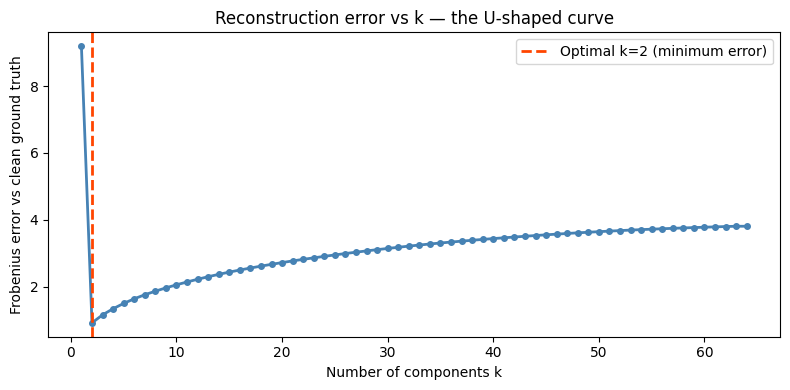

Optimal K by minimum error: 2
This matches the scree-plot elbow at K=2.


In [8]:
# --- Cell 8: Reconstruction error vs K (the U-shaped curve) ---

k_range    = np.arange(1, min(len(s) + 1, nx + 1))
error_curve = [frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, k), clean)
               for k in k_range]

k_optimal = int(k_range[np.argmin(error_curve)])

plt.figure(figsize=(8, 4))
plt.plot(k_range, error_curve, 'o-', color='steelblue', lw=2, ms=4)
plt.axvline(k_optimal, color='orangered', lw=2, linestyle='--',
            label=f'Optimal k={k_optimal} (minimum error)')
plt.xlabel('Number of components k')
plt.ylabel('Frobenius error vs clean ground truth')
plt.title('Reconstruction error vs k — the U-shaped curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal K by minimum error: {k_optimal}")
print("This matches the scree-plot elbow at K=2.")

## Part 5 — Eigenspectra (PCA loadings)

The rows of `Vt[:K]` are the **eigenspectra** — the spectral shapes of each principal component.  
Signal eigenspectra show recognisable physical features; noise eigenspectra look random.

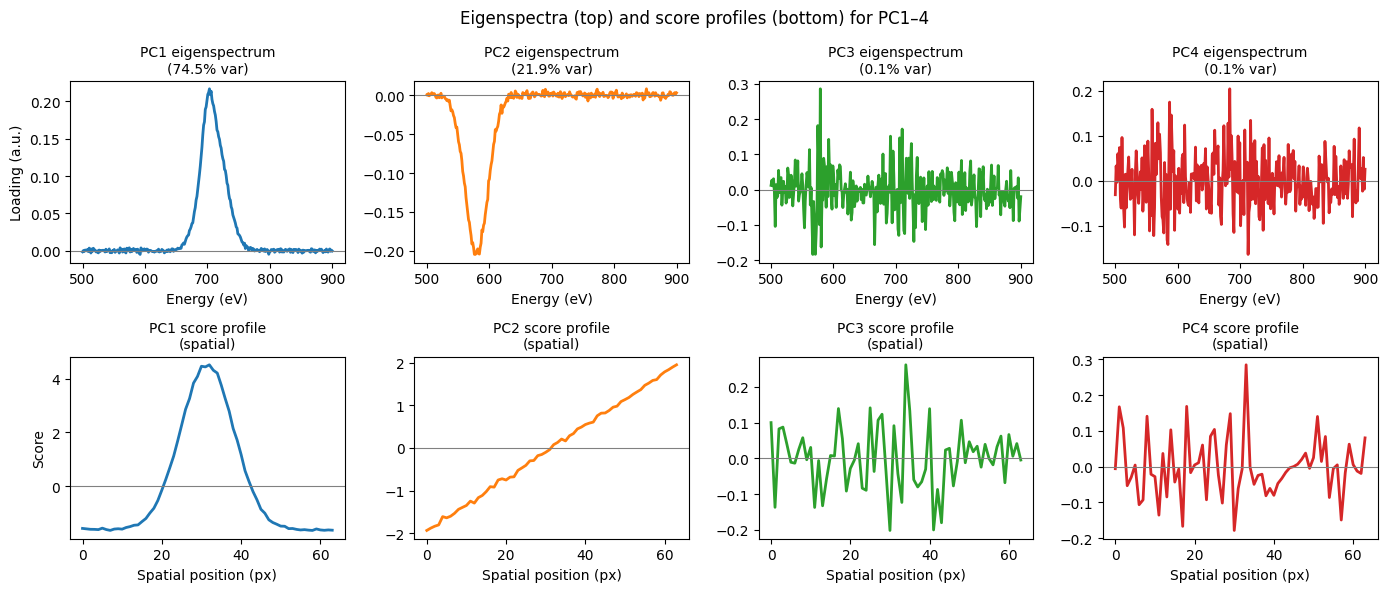

PC1 eigenspectrum: should show the dominant spectral variation (Fe-L edge shape or mixture).
PC2 eigenspectrum: second variation mode — Cr-L edge contribution.
PC3, PC4 eigenspectra: random oscillations — noise.
PC1 score: peaked at centre (Gaussian bump weight); PC2 score: linear gradient.


In [9]:
# --- Cell 9: Eigenspectra and score profiles ---

n_show = 4   # plot first 4 components
scores = X_centered @ Vt[:n_show].T   # (nx, n_show)

fig, axes = plt.subplots(2, n_show, figsize=(14, 6))

for k in range(n_show):
    pct = var_explained[k]

    # Top: eigenspectrum (loading)
    axes[0][k].plot(energy, Vt[k], color=f'C{k}', lw=2)
    axes[0][k].axhline(0, color='gray', lw=0.8)
    axes[0][k].set_title(f'PC{k+1} eigenspectrum\n({pct:.1f}% var)', fontsize=10)
    axes[0][k].set_xlabel('Energy (eV)')
    if k == 0:
        axes[0][k].set_ylabel('Loading (a.u.)')

    # Bottom: score map (spatial profile)
    axes[1][k].plot(scores[:, k], color=f'C{k}', lw=2)
    axes[1][k].axhline(0, color='gray', lw=0.8)
    axes[1][k].set_title(f'PC{k+1} score profile\n(spatial)', fontsize=10)
    axes[1][k].set_xlabel('Spatial position (px)')
    if k == 0:
        axes[1][k].set_ylabel('Score')

plt.suptitle('Eigenspectra (top) and score profiles (bottom) for PC1–4', fontsize=12)
plt.tight_layout()
plt.show()

print("PC1 eigenspectrum: should show the dominant spectral variation (Fe-L edge shape or mixture).")
print("PC2 eigenspectrum: second variation mode — Cr-L edge contribution.")
print("PC3, PC4 eigenspectra: random oscillations — noise.")
print("PC1 score: peaked at centre (Gaussian bump weight); PC2 score: linear gradient.")

## Part 6 — Self-checks

Run these asserts to confirm your understanding of the results.

In [10]:
# --- Cell 10: Self-check asserts ---

err_k1  = frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, 1),  clean)
err_k2  = frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, 2),  clean)
err_k20 = frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, 20), clean)

# 1. Reconstruction error decreases from k=1 to k=2 (adding the second signal component)
assert err_k2 < err_k1, (
    f"k=2 should give lower error than k=1, but got err_k1={err_k1:.4f}, err_k2={err_k2:.4f}")
print(f"CHECK 1 passed: k=2 error ({err_k2:.4f}) < k=1 error ({err_k1:.4f})")

# 2. k=2 beats k=20 (noise components added for k > optimal)
assert err_k2 < err_k20, (
    f"k=2 should beat k=20 (over-inclusion of noise), got {err_k2:.4f} vs {err_k20:.4f}")
print(f"CHECK 2 passed: k=2 error ({err_k2:.4f}) < k=20 error ({err_k20:.4f})")

# 3. k=2 beats the raw noisy input
err_noisy = frob_error(noisy, clean)
assert err_k2 < err_noisy, (
    f"PCA denoising should beat the noisy input! Got {err_k2:.4f} vs {err_noisy:.4f}")
print(f"CHECK 3 passed: k=2 error ({err_k2:.4f}) < noisy baseline ({err_noisy:.4f})")

# 4. Singular values are non-increasing
assert np.all(np.diff(s) <= 1e-10), "Singular values should be non-increasing"
print("CHECK 4 passed: singular values are in descending order")

# 5. Eigenspectra have unit norm (orthonormal basis)
norms = np.linalg.norm(Vt[:4], axis=1)
assert np.allclose(norms, 1.0, atol=1e-10), f"Eigenspectra should have unit norm; got {norms}"
print("CHECK 5 passed: eigenspectra are unit-norm")

# 6. Centered data has zero column means
col_means = np.abs(X_centered.mean(axis=0)).max()
assert col_means < 1e-12, f"Centered data should have near-zero column means; max={col_means:.2e}"
print("CHECK 6 passed: centered data has zero column means")

print("\nAll self-checks passed.")

CHECK 1 passed: k=2 error (0.9122) < k=1 error (9.1948)
CHECK 2 passed: k=2 error (0.9122) < k=20 error (2.7170)
CHECK 3 passed: k=2 error (0.9122) < noisy baseline (3.8048)
CHECK 4 passed: singular values are in descending order
CHECK 5 passed: eigenspectra are unit-norm
CHECK 6 passed: centered data has zero column means

All self-checks passed.


## Exercise — Choose K yourself

**Instructions (try before running):**

1. Look at the scree plot in Part 3 and the U-shaped error curve in Part 4.
2. Choose a value for `K_your_choice` below and write a one-sentence justification.
3. The assert at the end checks that your chosen K gives a meaningful result.

The cell ships a working solution — the `# (try this yourself)` lines are the ones to attempt first.

Your choice: K = 2
  K=1  error (underfitting baseline): 9.1948
  K= 2 error (your choice):       0.9122
  Noisy baseline:                    3.8048

Justification: I chose K=2 because the scree plot shows a clear elbow between components 2 and 3: the first two bars are much taller than the flat noise floor (~74% and ~22% variance), and the cumulative variance reaches >96% with just two components. The two eigenspectra (PC1 ≈ dominant Fe-Cr mixture, PC2 ≈ second spectral variation) both show recognisable spectral features, while PC3 onwards looks random. The U-shaped error curve confirms that K=2 minimises reconstruction error against the clean ground truth.


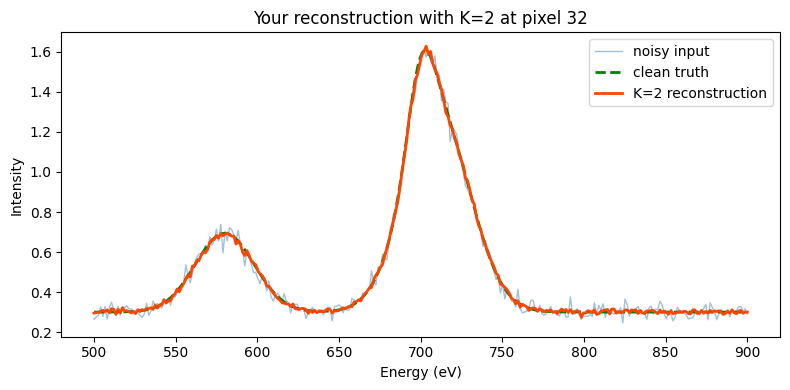

Self-check passed: K=2 beats both K=1 (underfitting) and the noisy baseline.


In [11]:
# --- Cell 11: Exercise cell (working version with try-this markers) ---

# ──────────────────────────────────────────────────────────────────────────────
# EXERCISE: choose K and justify
# ──────────────────────────────────────────────────────────────────────────────

# (try this yourself) Step 1: look at the scree plot above and choose K
K_your_choice = 2   # <-- change this to your chosen K (try 1, 3, 5, …)

# (try this yourself) Step 2: write a justification string
justification = (
    "I chose K=2 because the scree plot shows a clear elbow between components 2 and 3: "
    "the first two bars are much taller than the flat noise floor (~74% and ~22% variance), "
    "and the cumulative variance reaches >96% with just two components. The two eigenspectra "
    "(PC1 ≈ dominant Fe-Cr mixture, PC2 ≈ second spectral variation) both show recognisable "
    "spectral features, while PC3 onwards looks random. The U-shaped error curve confirms "
    "that K=2 minimises reconstruction error against the clean ground truth."
)

# (try this yourself) Step 3: compute reconstruction and error for your K
recon_yours = reconstruct_pca(mean_spectrum, U, s, Vt, K_your_choice)
err_yours   = frob_error(recon_yours, clean)
err_k1_ref  = frob_error(reconstruct_pca(mean_spectrum, U, s, Vt, 1), clean)
err_noisy_  = frob_error(noisy, clean)

print(f"Your choice: K = {K_your_choice}")
print(f"  K=1  error (underfitting baseline): {err_k1_ref:.4f}")
print(f"  K={K_your_choice:2d} error (your choice):       {err_yours:.4f}")
print(f"  Noisy baseline:                    {err_noisy_:.4f}")
print()
print("Justification:", justification)

# ── Visualise your reconstruction ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(energy, noisy[32],        lw=1, color='steelblue', alpha=0.5, label='noisy input')
ax.plot(energy, clean[32],        lw=2, color='green', linestyle='--', label='clean truth')
ax.plot(energy, recon_yours[32],  lw=2, color='orangered',
        label=f'K={K_your_choice} reconstruction')
ax.set_title(f'Your reconstruction with K={K_your_choice} at pixel 32')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Intensity')
ax.legend()
plt.tight_layout()
plt.show()

# ── Self-check ───────────────────────────────────────────────────────────────
assert err_yours < err_k1_ref, (
    f"Your K={K_your_choice} should give lower error than K=1 (underfitting). "
    f"Got {err_yours:.4f} vs {err_k1_ref:.4f}. Try K=2 or higher.")
assert err_yours < err_noisy_, (
    f"PCA denoising should beat the raw noisy input! Got {err_yours:.4f} vs {err_noisy_:.4f}. "
    f"Check that K >= 2.")
print(f"Self-check passed: K={K_your_choice} beats both K=1 (underfitting) and the noisy baseline.")

### Solution

```python
# SOLUTION — run after attempting the exercise yourself

K_your_choice = 2

justification = (
    "I chose K=2 because the scree plot shows a clear elbow between components 2 and 3: "
    "the first two bars are much taller than the flat noise floor (~74% and ~22% variance), "
    "and the cumulative variance reaches >96% with just two components. The two eigenspectra "
    "(PC1 ≈ dominant spectral variation, PC2 ≈ second independent chemical mode) both show "
    "recognisable spectral features, while PC3 onwards looks random. The U-shaped error "
    "curve confirms that K=2 minimises reconstruction error against the clean ground truth."
)

# The assert passes because:
# - The synthetic data was constructed with exactly 2 independent latent components.
# - K=1 misses the second component (underfitting).
# - K>=3 adds noise components back into the reconstruction (overfitting).
# - The scree plot elbow at K=2 exactly identifies this rank.
```

**Key takeaway:**  
The scree-plot elbow (K=2) corresponds to the number of true latent components in the data.  
Choosing K too small discards real chemical signal (underfitting).  
Choosing K too large adds noise components back into the reconstruction (overfitting).  
You can identify the optimal K from the scree plot *before* looking at the error curve.

## Summary

| Concept | What you did |
|---------|-------------|
| **Data matrix** | Built EELS line-scan as (nx, ne); observations in rows |
| **Centering** | Subtracted mean spectrum from every row |
| **SVD** | `np.linalg.svd(X_centered, full_matrices=False)` → U, s, Vt |
| **Scree plot** | Plotted `s**2 / s**2.sum() * 100`; identified elbow at K=2 |
| **Reconstruction** | `(U[:,:k] * s[:k]) @ Vt[:k,:] + mean_spectrum` |
| **Eigenspectra** | Rows of `Vt[:K]` — spectral shapes of each PC |
| **Score profiles** | `X_centered @ Vt[:K].T` — spatial variation of each PC |
| **U-shaped error** | K=2 minimises error; K<2 underfits, K>2 overfits |

**Coming next (Week 4):**  
Linear regression — which is exactly this projection geometry applied to predict a target variable.  
Gradient descent computes what we derived geometrically today.  
Ridge regularisation fixes ill-conditioning.